# 03 — Health & economic cost
*The Price of Lahore's Air.*

Translating the reconstructed PM2.5 series into attributable mortality and a
rupee cost. All computation lives in `src/07_health_cost.py`; this notebook
reads its tidy outputs and explains the method and the honest range.

**Method in one paragraph.** Lahore District population (WorldPop 2020) is
split by age using the GBD 2023 Punjab age structure. Age-specific NCD+LRI
baseline death rates (GBD 2023, Punjab) give baseline deaths. The GEMM
(Burnett et al. 2018) concentration–response function converts annual-mean
PM2.5 into an attributable fraction per age band, relative to a counterfactual
(WHO 5, Pakistan NEQS 15, or the GEMM TMREL of 2.4 µg/m³). Deaths are valued
with a Value of a Statistical Life transferred to Pakistan by income scaling.
Everything is stress-tested in a sensitivity grid and reconciled against
national GBD / World Bank figures.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
FIG = '../figures'
P = '../data/processed'

summary = json.load(open(f'{P}/cost_summary.json'))
headline = pd.read_csv(f'{P}/cost_headline.csv')
scenarios = pd.read_csv(f'{P}/cost_scenarios.csv')
sens = pd.read_csv(f'{P}/cost_sensitivity.csv')

print(f"Population: {summary['population']/1e6:.2f} M")
print(f"Baseline NCD+LRI deaths (25+): {summary['baseline_ncdlri_deaths_25plus']:,}/yr")
print(f"Annual-mean PM2.5 (multi-year): {summary['exposure_multiyear_ugm3']} µg/m³")
print(f"VSL Pakistan (central): ${summary['vsl_pakistan_usd_central']:,}")
headline

Population: 10.84 M
Baseline NCD+LRI deaths (25+): 73,841/yr
Annual-mean PM2.5 (multi-year): 123.6 µg/m³
VSL Pakistan (central): $74,793


,counterfactual,cf_ugm3,attributable_deaths,cost_usd_bn,cost_pkr_bn
0,WHO guideline (5),5.0,19709,1.47,408.3
1,Pakistan NEQS (15),15.0,15742,1.18,326.1
2,GEMM TMREL (2.4),2.4,22268,1.67,461.3


### The headline

Against the **WHO guideline**, Lahore's PM2.5 is associated with roughly
**20,000 premature NCD+LRI deaths per year** and a central economic cost near
**PKR 400 billion (~USD 1.5 bn)**. Against the stricter GEMM TMREL the number
rises; against the more lenient Pakistan NEQS it falls. These are the central
estimates — the range below is the honest headline.

## The concentration–response curve

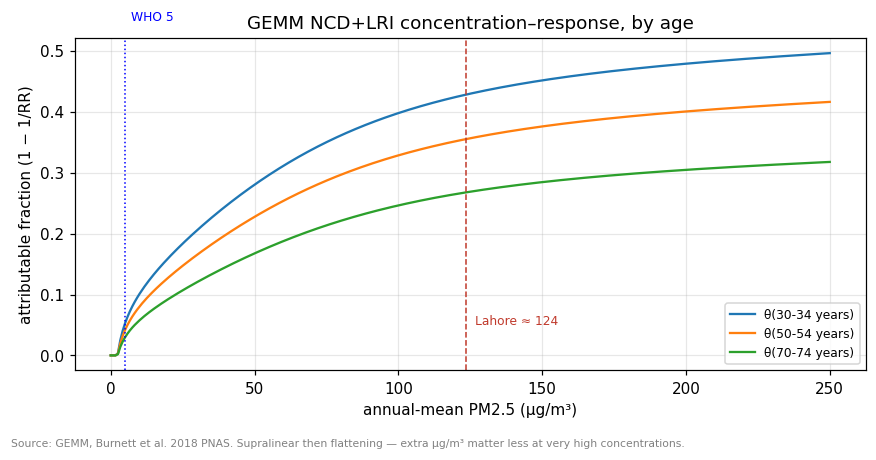

In [2]:
from sys import path; path.insert(0, '../src')
from utils.health import gemm_af, GEMM_THETA
z = np.linspace(0, 250, 300)
fig, ax = plt.subplots(figsize=(8, 4))
for age in ['30-34 years', '50-54 years', '70-74 years']:
    af = [gemm_af(x, GEMM_THETA[age]) for x in z]
    ax.plot(z, af, label=f'θ({age})')
ax.axvline(summary['exposure_multiyear_ugm3'], color='#c0392b', ls='--', lw=1)
ax.text(summary['exposure_multiyear_ugm3']+3, 0.05,
        f"Lahore ≈ {summary['exposure_multiyear_ugm3']:.0f}", color='#c0392b', fontsize=8)
ax.axvline(5, color='blue', ls=':', lw=1); ax.text(7, 0.55, 'WHO 5', color='blue', fontsize=8)
ax.set(xlabel='annual-mean PM2.5 (µg/m³)', ylabel='attributable fraction (1 − 1/RR)',
       title='GEMM NCD+LRI concentration–response, by age')
ax.legend(fontsize=8)
fig.text(.01,-.03,'Source: GEMM, Burnett et al. 2018 PNAS. Supralinear then flattening — extra µg/m³ matter less at very high concentrations.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/cost_cr_curve.png', bbox_inches='tight'); plt.show()

The curve is **supralinear then saturating**: at Lahore's extreme
concentrations, each additional µg/m³ adds relatively little risk — which is
precisely why a modest peak-shaving scenario saves fewer lives than meeting
the guideline outright.

## Scenarios — what cleaner air would buy

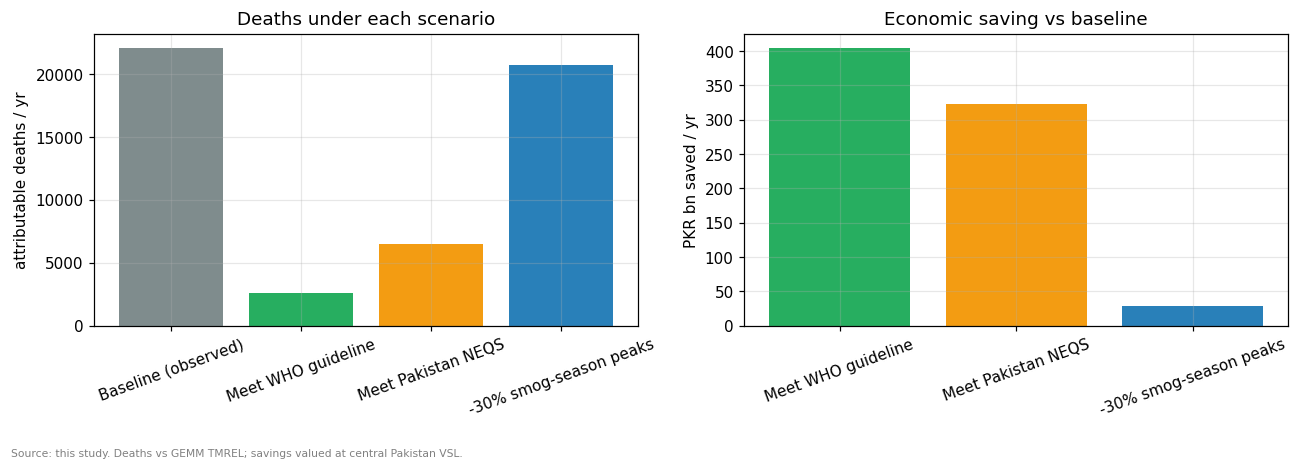

,scenario,annual_pm25,attributable_deaths,avoided_vs_baseline,pkr_bn_saved
0,Baseline (observed),121.1,22115,0,0.0
1,Meet WHO guideline,5.0,2558,19556,405.2
2,Meet Pakistan NEQS,15.0,6525,15589,323.0
3,-30% smog-season peaks,102.5,20756,1358,28.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
s = scenarios
axes[0].bar(s.scenario, s.attributable_deaths, color=['#7f8c8d','#27ae60','#f39c12','#2980b9'])
axes[0].set_ylabel('attributable deaths / yr'); axes[0].set_title('Deaths under each scenario')
axes[0].tick_params(axis='x', rotation=20)
avoided = s[s.avoided_vs_baseline > 0]
axes[1].bar(avoided.scenario, avoided.pkr_bn_saved, color=['#27ae60','#f39c12','#2980b9'])
axes[1].set_ylabel('PKR bn saved / yr'); axes[1].set_title('Economic saving vs baseline')
axes[1].tick_params(axis='x', rotation=20)
fig.text(.01,-.05,'Source: this study. Deaths vs GEMM TMREL; savings valued at central Pakistan VSL.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/cost_scenarios.png', bbox_inches='tight'); plt.show()
scenarios

## Cost waterfall — from baseline burden to residual

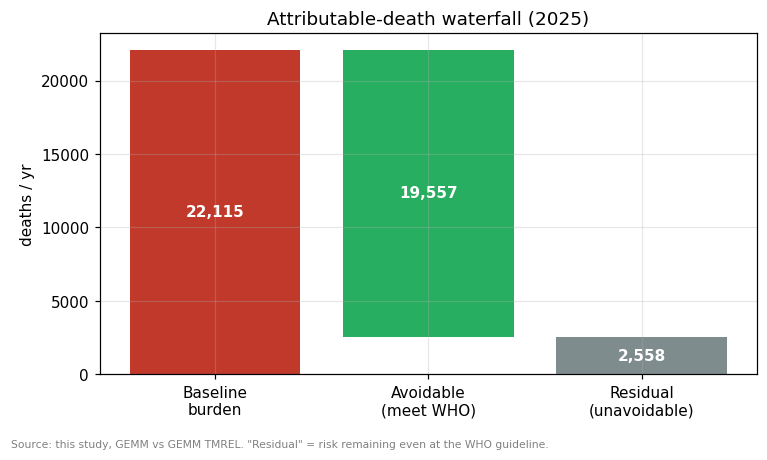

In [4]:
base = scenarios.loc[scenarios.scenario=='Baseline (observed)','attributable_deaths'].iloc[0]
who = scenarios.loc[scenarios.scenario=='Meet WHO guideline','attributable_deaths'].iloc[0]
avoid = base - who
fig, ax = plt.subplots(figsize=(7,4))
ax.bar('Baseline\nburden', base, color='#c0392b')
ax.bar('Avoidable\n(meet WHO)', avoid, bottom=who, color='#27ae60')
ax.bar('Residual\n(unavoidable)', who, color='#7f8c8d')
for x,v,b in [('Baseline\nburden',base,0),('Avoidable\n(meet WHO)',avoid,who),('Residual\n(unavoidable)',who,0)]:
    ax.text(x, b+v/2, f'{v:,.0f}', ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('deaths / yr'); ax.set_title('Attributable-death waterfall (2025)')
fig.text(.01,-.03,'Source: this study, GEMM vs GEMM TMREL. "Residual" = risk remaining even at the WHO guideline.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/cost_waterfall.png', bbox_inches='tight'); plt.show()

## Sensitivity — the honest range

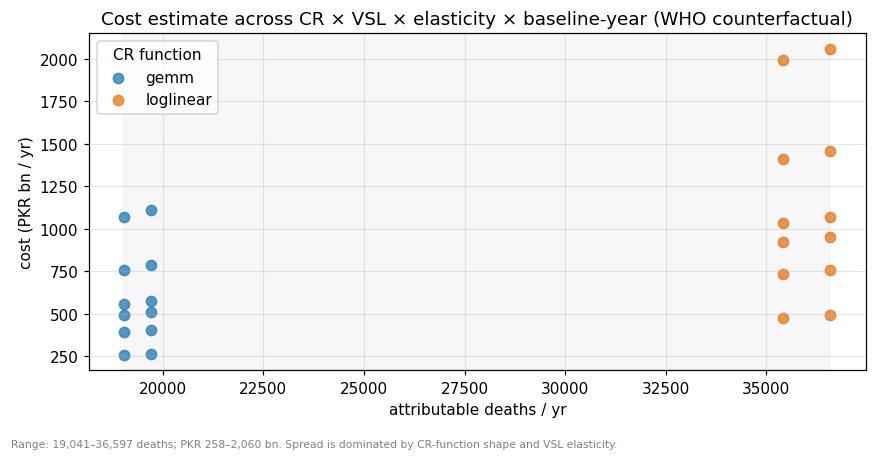

,deaths_min,deaths_max,pkr_bn_min,pkr_bn_max
cr,,,,
gemm,19041,19709,258.0,1109.0
loglinear,35410,36597,479.0,2060.0


In [5]:
fig, ax = plt.subplots(figsize=(8,4))
colors = {'gemm':'#2980b9','loglinear':'#e67e22'}
for cr, g in sens.groupby('cr'):
    ax.scatter(g.deaths, g.cost_pkr_bn, c=colors[cr], label=cr, s=45, alpha=.8)
ax.set(xlabel='attributable deaths / yr', ylabel='cost (PKR bn / yr)',
       title='Cost estimate across CR × VSL × elasticity × baseline-year (WHO counterfactual)')
ax.legend(title='CR function')
d = summary['deaths_range']; c = summary['cost_pkr_bn_range']
ax.axvspan(d[0], d[1], alpha=.06, color='gray')
fig.text(.01,-.03, f"Range: {d[0]:,}–{d[1]:,} deaths; PKR {c[0]:,.0f}–{c[1]:,.0f} bn. Spread is dominated by CR-function shape and VSL elasticity.", fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/cost_sensitivity.png', bbox_inches='tight'); plt.show()
sens.groupby('cr').agg(deaths_min=('deaths','min'), deaths_max=('deaths','max'),
                       pkr_bn_min=('cost_pkr_bn','min'), pkr_bn_max=('cost_pkr_bn','max')).round(0)

## Reconciliation & takeaways

- **Central headline:** ~20,000 premature deaths/yr and ~PKR 400 bn (~USD
  1.5 bn) versus the WHO guideline; honest range **19,041–36,597 deaths** and
  **PKR 258–2,060 bn** across defensible assumptions.
- **Reconciliation:** this is ~12–13% of Pakistan's national GBD 2021 PM2.5
  death total (~157,800) for a district holding ~4.5% of the population —
  consistent with Lahore being one of the world's most polluted cities. The
  older World Bank ~22,000 outdoor-death figure is now regarded as a large
  underestimate relative to GBD.
- **Caveats carried forward:** single-station ground truth; smog-season model
  error is largest exactly where exposure is highest; GEMM vs log-linear CR
  choice and VSL elasticity drive most of the spread; baseline rates are
  Punjab-level, not Lahore-specific. This is an *association-based burden*
  estimate, not a causal experiment.